# 1: Problem Definition (Quantum Noise Study)

## Quantum Noise Analysis using Bell State

This project demonstrates the effect of **quantum noise** on an entangled quantum system using a Bell state circuit.

### Objectives:
- Create an entangled Bell state
- Simulate ideal (noise-free) quantum behavior
- Introduce noise into the system
- Analyze how noise affects quantum outcomes

### Key Concept:
Quantum systems are highly sensitive to noise, which impacts the reliability of quantum computations.

In [ ]:
!pip install qiskit qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00


In [ ]:
# import libraries
from qiskit import QuantumCircuit

# 2. Bell State Circuit

## Bell State (Quantum Entanglement)

A Bell state is a maximally entangled quantum state of two qubits.

### Circuit Steps:
1. Apply Hadamard gate (H) to create superposition  
2. Apply CNOT gate (CX) to entangle qubits  
3. Measure both qubits  

### Expected Output:
Only two states should appear:
- `00`
- `11`

This indicates perfect entanglement.

In [ ]:
# Bell state circuit
# Create circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Step 1: Apply Hadamard to qubit 0
qc.h(0)

# Step 2: Apply CNOT (entangle qubits)
qc.cx(0, 1)

# Step 3: Measurement
qc.measure([0,1], [0,1])

# Draw circuit
qc.draw('text')

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

# 3. Ideal Simulation

## Ideal Simulation (No Noise)

We simulate the circuit using a noise-free quantum simulator.

### Goal:
To verify that the Bell state behaves as expected under ideal conditions.

### Expected Result:
- Only `00` and `11` should appear
- Both states should have approximately equal probability

In [ ]:
!pip install qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 30.7 MB/s eta 0:00:00


In [ ]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Ideal simulator (no noise)
simulator = AerSimulator()

# Run circuit
result = simulator.run(qc, shots=1024).result()

# Get counts
counts = result.get_counts()

print("Ideal Results:", counts)

# Plot results
plot_histogram(counts)
plt.show()

Ideal Results: {'11': 506, '00': 518}


# 4. Adding Noise

## Adding Quantum Noise

In real quantum systems, noise affects qubit states.

We simulate noise using a **depolarizing noise model**.

### Noise Details:
- 10% noise applied to:
  - Hadamard (H) gate
  - CNOT (CX) gate

### Purpose:
To observe how real-world imperfections affect quantum computations.

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer import AerSimulator

# Create noise model
noise_model = NoiseModel()

# Add depolarizing noise to single qubit gates
error_1 = depolarizing_error(0.1, 1)  # 10% noise
noise_model.add_all_qubit_quantum_error(error_1, ['h'])

# Add depolarizing noise to 2-qubit gates
error_2 = depolarizing_error(0.1, 2)
noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

# Create noisy simulator
noisy_simulator = AerSimulator(noise_model=noise_model)

# Run circuit with noise
noisy_result = noisy_simulator.run(qc, shots=1024).result()

# Get counts
noisy_counts = noisy_result.get_counts()

print("Noisy Results:", noisy_counts)

Noisy Results: {'10': 30, '00': 459, '01': 33, '11': 502}


## Noisy Simulation Results

After adding noise, additional states appear in the output.

### Observations:
- Correct states: `00`, `11`
- Error states: `01`, `10`

### Insight:
Noise introduces incorrect outcomes, reducing system reliability.

# 5. Comparison + Plot

## Histogram Comparison

We compare:
- Ideal results (no noise)
- Noisy results

### Purpose:
To visually demonstrate how noise affects probability distributions.

### Insight:
The histogram shows that noise redistributes probability from correct states (00, 11) to incorrect states (01, 10). Noise causes probability spread across incorrect states.

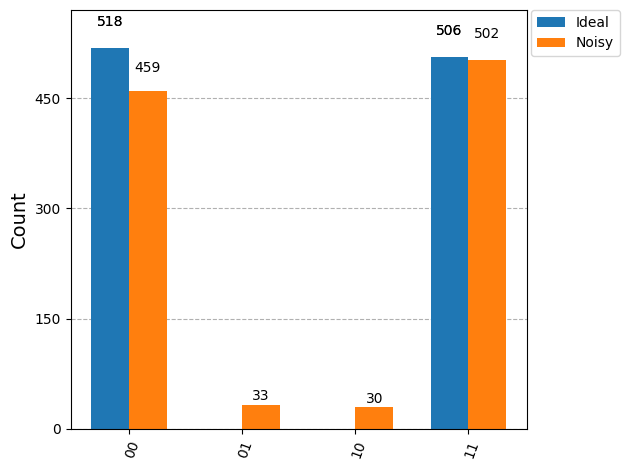

In [ ]:
from qiskit.visualization import plot_histogram

# Direct display (no plt.show)
plot_histogram(
    [counts, noisy_counts],
    legend=['Ideal', 'Noisy']
)

# 6. Noise Impact Analysis

## Noise Impact Analysis

We compute accuracy and error rate based on results.

### Metrics:
- Accuracy = Correct results / Total shots  
- Error Rate = Incorrect results / Total shots  

### Interpretation:
Higher noise leads to:
- Lower accuracy  
- Higher error rate  

In [ ]:
# comppute error metrices
# Total shots
total_shots = 1024

# Correct states (ideal Bell states)
correct_states = ['00', '11']

# Count correct results
correct_counts = sum(noisy_counts.get(state, 0) for state in correct_states)

# Count errors
error_counts = total_shots - correct_counts

# Compute percentages
accuracy = correct_counts / total_shots
error_rate = error_counts / total_shots

print("=== NOISE ANALYSIS ===")
print("Correct counts:", correct_counts)
print("Error counts:", error_counts)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Error rate:", round(error_rate * 100, 2), "%")

=== NOISE ANALYSIS ===
Correct counts: 961
Error counts: 63

Accuracy: 93.85 %
Error rate: 6.15 %


# 7. Noise Levels Experiment

## Effect of Different Noise Levels

We test multiple noise levels:
- 5%
- 10%
- 20%

### Objective:
To study how increasing noise impacts quantum results.

### Insight:
As noise increases:
- Correct states decrease
- Error states increase

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer import AerSimulator

noise_levels = [0.05, 0.10, 0.20]

results = {}

for noise in noise_levels:
    # Create noise model
    noise_model = NoiseModel()

    error_1 = depolarizing_error(noise, 1)
    error_2 = depolarizing_error(noise, 2)

    noise_model.add_all_qubit_quantum_error(error_1, ['h'])
    noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

    # Simulator
    simulator = AerSimulator(noise_model=noise_model)

    # Run
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    results[noise] = counts

# Print results
for noise, counts in results.items():
    print(f"\nNoise Level {noise}:")
    print(counts)


Noise Level 0.05:
{'01': 9, '10': 11, '00': 486, '11': 518}

Noise Level 0.1:
{'01': 29, '11': 472, '10': 26, '00': 497}

Noise Level 0.2:
{'01': 53, '11': 484, '10': 63, '00': 424}


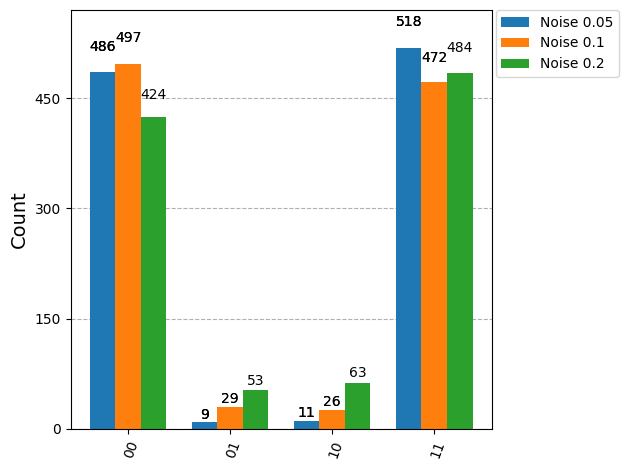

In [ ]:
# visualization
from qiskit.visualization import plot_histogram

plot_histogram(
    list(results.values()),
    legend=[f"Noise {n}" for n in noise_levels]
)

# 8. Conclusion

This project demonstrates how quantum noise affects entangled systems.

### Key Findings:
- Ideal quantum systems produce perfectly correlated results
- Noise introduces errors and reduces accuracy
- Higher noise levels significantly degrade performance

### Real-World Insight:
Quantum computers are highly sensitive to noise, making error mitigation a critical area of research.

### Final Takeaway:
While quantum computing offers powerful advantages, managing noise remains a major challenge for practical applications.